# Block 3 — Time Series Data with ARIMA Models

**Goals for this block:**
- Understand and implement **ARIMA** for non-seasonal time series.
- Extend to **SARIMA** to model data with seasonal patterns.
- Use **`auto_arima`** for automatic hyperparameter tuning.

## 0. Setup & Environment

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

We load the train, validation and test from the previous block

In [2]:
train_preprocessed = pd.read_parquet('train_preprocessed.parquet')
test_preprocessed = pd.read_parquet('test_preprocessed.parquet')

In [3]:
# Naive Forecasting Model
naive_forecast = test_preprocessed['value'].iloc[-1]

In [4]:
test_preprocessed["Naive_Forecast"] = test_preprocessed['value'].shift(1, fill_value=test_preprocessed['value'].iloc[0])

In [5]:
test_preprocessed.round(2)

,value,Naive_Forecast
timestamp,,
2023-05-26,0.12,0.12
2023-05-27,1.31,0.12
2023-05-28,2.05,1.31
2023-05-29,1.74,2.05
2023-05-30,0.65,1.74
...,...,...
2023-12-27,0.37,1.50
2023-12-28,0.25,0.37
2023-12-29,0.84,0.25


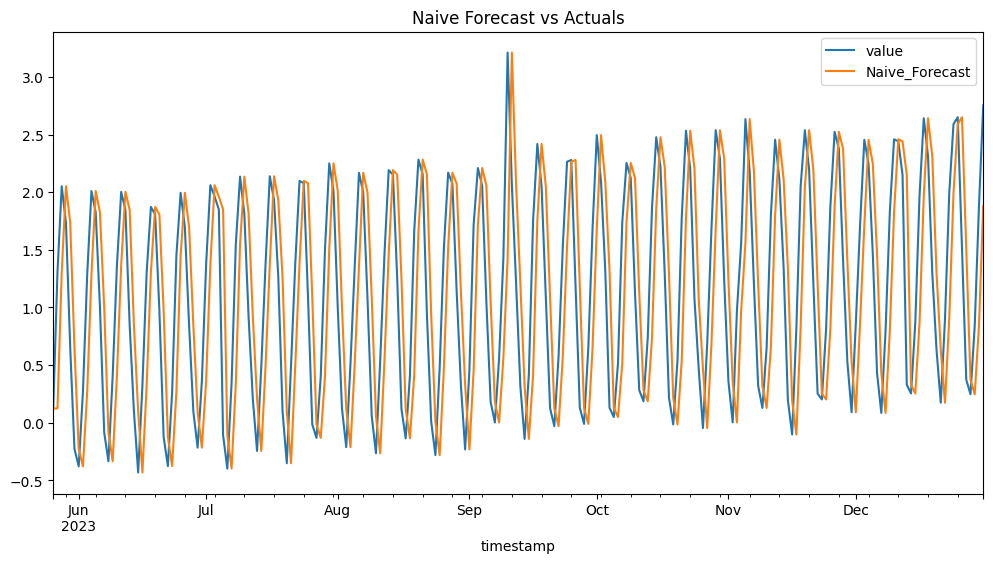

In [6]:
test_preprocessed.plot(y=['value', 'Naive_Forecast'], figsize=(12,6), title='Naive Forecast vs Actuals')
plt.show()

## 1. ARIMA Models

ARIMA stands for **A**uto**R**egressive **I**ntegrated **M**oving **A**verage. It's a powerful class of models that captures temporal structures in time series data.

### Components of ARIMA:

-   **AR (p) - Autoregressive**: This component models the relationship between an observation and a number of lagged observations (past values). The parameter `p` is the order of the AR part. We can use the **Partial Autocorrelation Function (PACF)** plot to help determine `p`.

-   **I (d) - Integrated**: This component is used to make the time series stationary by using differencing. The parameter `d` is the number of times the data has been differenced. If `d=0`, we are essentially using an ARMA model.

-   **MA (q) - Moving Average**: This component models the relationship between an observation and the residual errors from a moving average model applied to lagged observations. The parameter `q` is the order of the MA part. We can use the **Autocorrelation Function (ACF)** plot to help determine `q`.

### The Process:

1.  **Visualize the data** to check for trends and seasonality.
2.  **Make the series stationary** using differencing (determines `d`).
3.  **Examine ACF and PACF plots** of the stationary series to determine the `p` and `q` values.
4.  **Build the ARIMA(p, d, q) model**.
5.  **Evaluate the model's performance** against the test set and compare it to our naive baseline.

Let's start by finding the right parameters for our model.

#### 1.  **Visualize the data** to check for trends and seasonality.

<Axes: title={'center': 'Training Data Sample'}, xlabel='timestamp'>

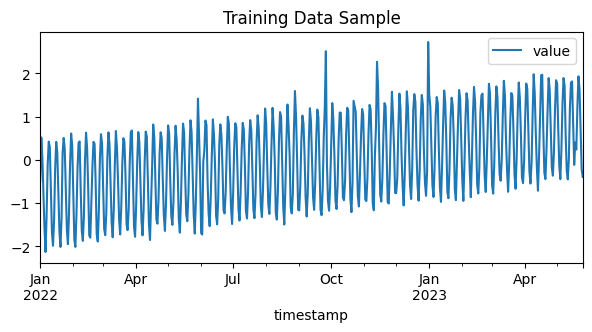

In [7]:
train_preprocessed.plot(y=['value'], figsize=(7,3), title='Training Data Sample')

<Axes: title={'center': 'Training Data Sample'}, xlabel='timestamp'>

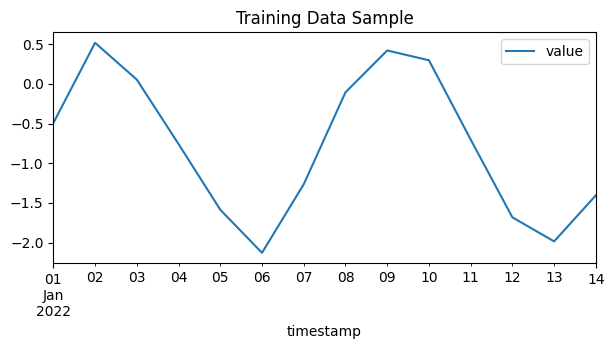

In [8]:
train_preprocessed[:14].plot(y=['value'], figsize=(7,3), title='Training Data Sample')

#### 2.  **Make the series stationary** using differencing (trend order 1).


<Axes: xlabel='timestamp'>

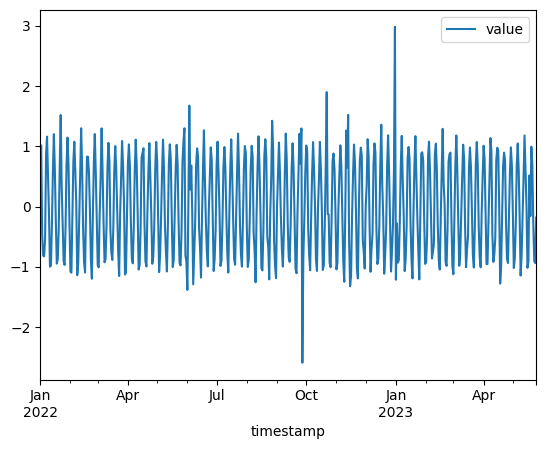

In [9]:
train_preprocessed.diff(1).plot()

#### 3. **Examine ACF and PACF plots**

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

The ACF and PACF curves should be considered together to define the process. For an AR process, we expect the ACF curve to gradually decline and, at the same time, the PACF curve to show a sharp drop after p significant lags. To define an MA process, we expect the opposite from the ACF and PACF plots, i.e., the ACF should show a sharp decline after a certain number q of lags, while the PACF should show a geometric or gradually declining trend. If, on the other hand, both the ACF and PACF curves show a gradually decreasing pattern, then the ARMA process should be considered for modeling.

In [11]:
train_differenciated = train_preprocessed.diff(1).dropna()

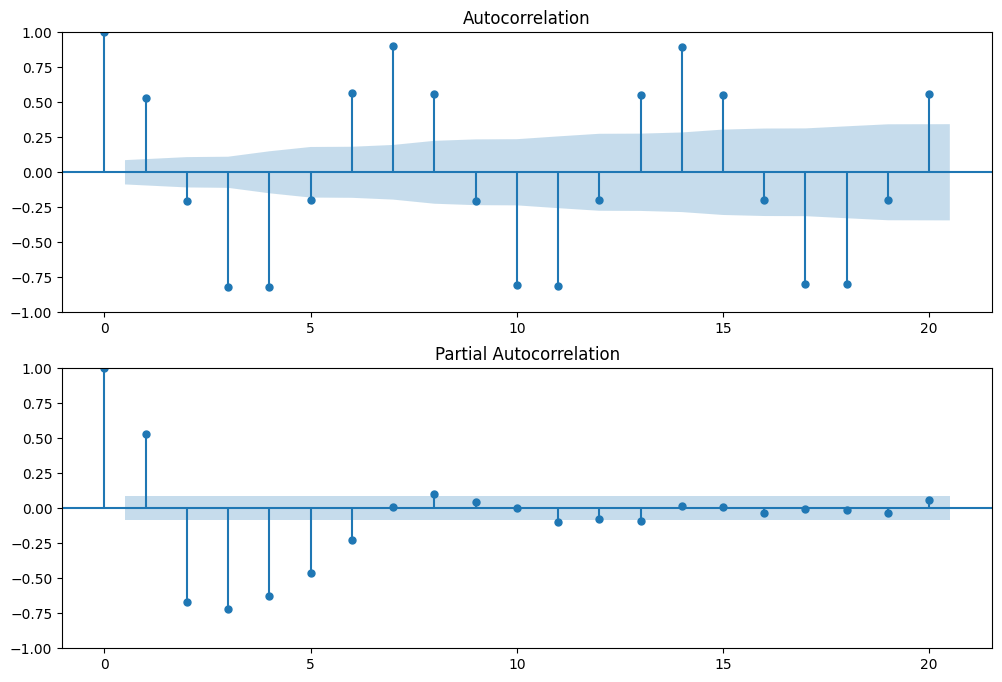

In [12]:
# Step 1: Determine ARIMA parameters (p, d, q) by looking at ACF/PACF plots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_differenciated, lags=20, ax=axes[0])
plot_pacf(train_differenciated, lags=20, ax=axes[1])
plt.show()

Interpretation:
- PACF (bottom plot) has a sharp cutoff after lag 1, suggesting p=1.
- ACF (top plot) has a sharp cutoff after lag 1, suggesting q=1.
- We use d=1 for differencing.
- A good starting model is ARIMA(1, 1, 1).

#### 4.  **Build the ARIMA(p, d, q) model**.

In [13]:
# Step 2: Define and fit the ARIMA model
# order=(p, d, q)
arima_model = SARIMAX(train_preprocessed['value'], 
                      order=(1, 1, 1))
arima_results = arima_model.fit()

print(arima_results.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  510
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -479.061
Date:                Mon, 01 Dec 2025   AIC                            964.122
Time:                        18:14:51   BIC                            976.820
Sample:                    01-01-2022   HQIC                           969.101
                         - 05-25-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3325      0.060      5.582      0.000       0.216       0.449
ma.L1          0.4320      0.049      8.733      0.000       0.335       0.529
sigma2         0.3842      0.020     19.060      0.0

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


#### 5.  **Evaluate on the Test set**.

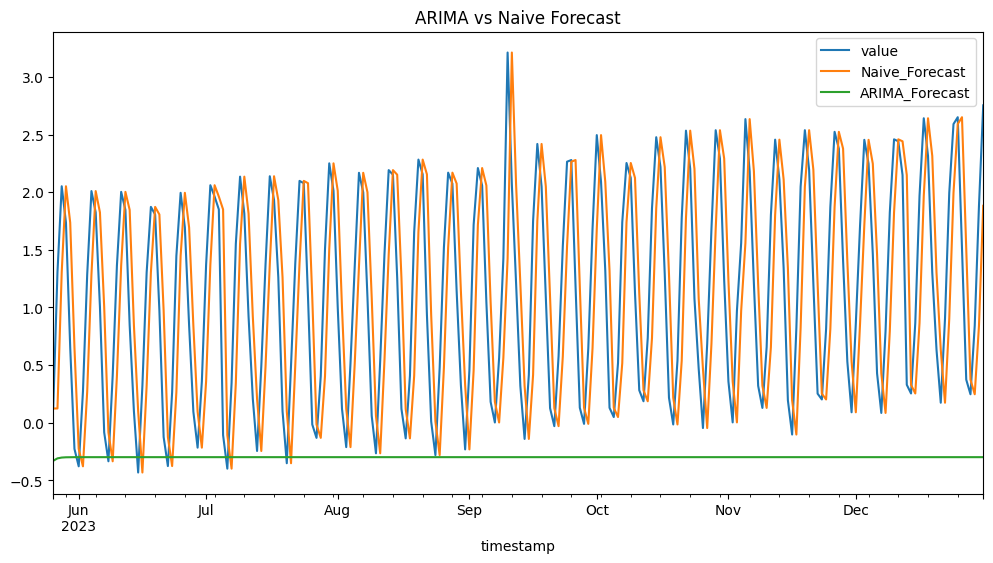

In [14]:
# Step 3: Make predictions
# We predict for the same number of steps as the length of our test set
n_steps = len(test_preprocessed)
arima_pred = arima_results.get_forecast(steps=n_steps)
arima_pred_mean = arima_pred.predicted_mean

# Add predictions to the test dataframe
test_preprocessed['ARIMA_Forecast'] = arima_pred_mean

# Step 4: Plot the results
test_preprocessed.plot(y=['value', 'Naive_Forecast', 'ARIMA_Forecast'], figsize=(12,6), title='ARIMA vs Naive Forecast')
plt.show()

## 2. SARIMA Models

While ARIMA is great for capturing trend, it falls short when the data has a clear **seasonal component**. This is where **SARIMA** (Seasonal AutoRegressive Integrated Moving Average) comes in.

SARIMA extends ARIMA by adding a new set of seasonal parameters: `(P, D, Q, s)`.

### Components of SARIMA:

The model is described as `SARIMA(p, d, q)(P, D, Q)s`:

-   **(p, d, q)**: These are the non-seasonal parameters, the same as in ARIMA.
    -   `p`: Non-seasonal AR order.
    -   `d`: Non-seasonal differencing.
    -   `q`: Non-seasonal MA order.

-   **(P, D, Q)s**: These are the new seasonal components.
    -   `P`: **Seasonal AR order**. This is the number of seasonal lagged observations (e.g., the value from the same time last week).
    -   `D`: **Seasonal differencing**. This is the number of times a seasonal difference is applied to the data (e.g., `value(t) - value(t-s)`).
    -   `Q`: **Seasonal MA order**. This is the number of seasonal lagged forecast errors.
    -   `s`: **The seasonal period**. This is the number of time steps in a single seasonal cycle (e.g., `s=7` for daily data with a weekly pattern, `s=12` for monthly data with a yearly pattern).

<Axes: xlabel='timestamp'>

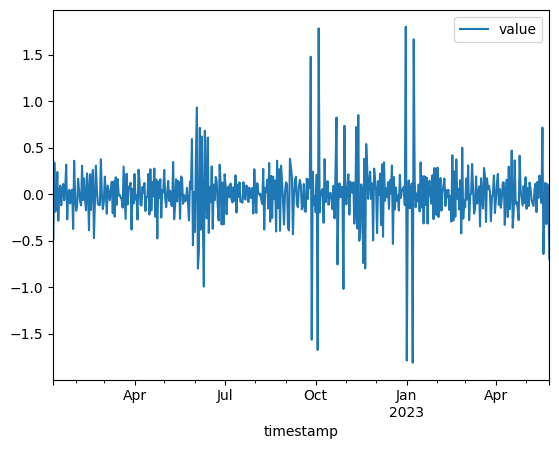

In [15]:
train_differenciated = train_preprocessed.diff(7).diff(1).dropna()
train_differenciated.plot()

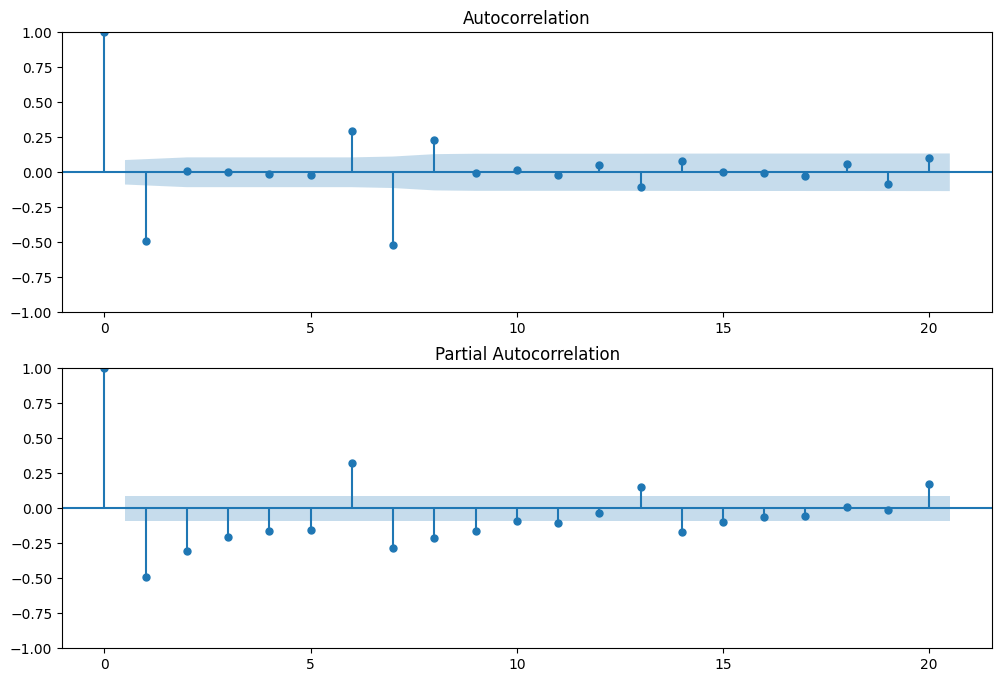

In [16]:
# Step 1: Determine SARIMA parameters by looking at ACF/PACF plots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_differenciated, lags=20, ax=axes[0])
plot_pacf(train_differenciated, lags=20, ax=axes[1])
plt.show()

In [17]:
# Step 2: Define and fit the ARIMA model
# order=(p, d, q) 
# seasonal_order=(P, D, Q, s)
arima_model = SARIMAX(train_preprocessed['value'], 
                order=(1, 1, 1),
                seasonal_order=(0, 1, 1, 7))
arima_results = arima_model.fit()

print(arima_results.summary())

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             value   No. Observations:                  510
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood                 165.511
Date:                           Mon, 01 Dec 2025   AIC                           -323.022
Time:                                   18:14:52   BIC                           -306.148
Sample:                               01-01-2022   HQIC                          -316.402
                                    - 05-25-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0185      0.047      0.394      0.694      -0.074       0.111
ma.L1         -0.9995      0.290     -3.448

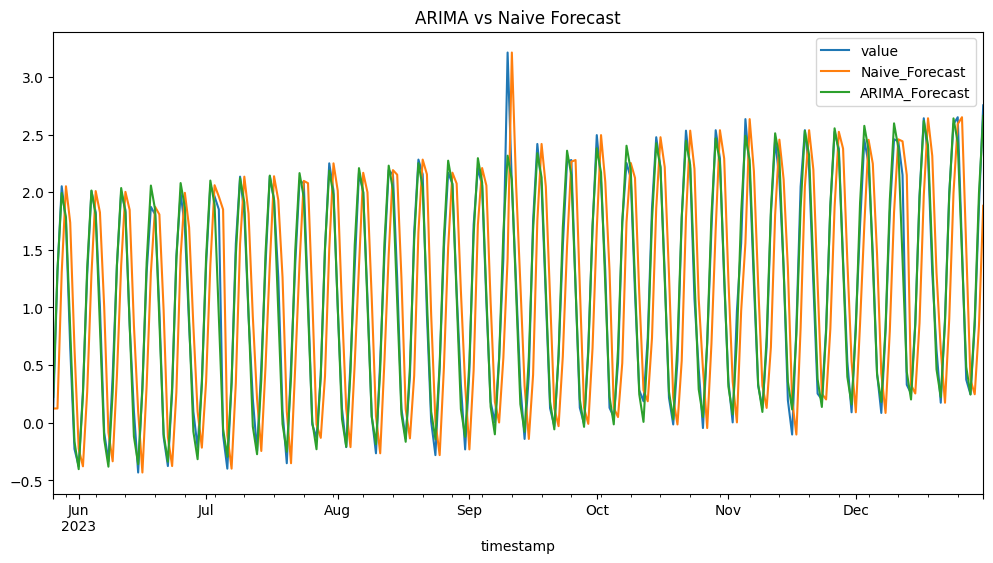

In [18]:
# Step 3: Make predictions
# We predict for the same number of steps as the length of our test set
n_steps = len(test_preprocessed)
arima_pred = arima_results.get_forecast(steps=n_steps)
arima_pred_mean = arima_pred.predicted_mean

# Add predictions to the test dataframe
test_preprocessed['ARIMA_Forecast'] = arima_pred_mean

# Step 4: Plot the results
test_preprocessed.plot(y=['value', 'Naive_Forecast', 'ARIMA_Forecast'], figsize=(12,6), title='ARIMA vs Naive Forecast')
plt.show()

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Train SARIMA</h2>

Apply what you've learned to the electricity dataset:
1. **Load the preprocessed data**: Load `train_preprocessed_ex.parquet` and `test_preprocessed_ex.parquet` that you created in the previous block.
2. **Select a Target**: Choose one energy source to forecast (e.g., 'Solar' or 'Wind').
3. **Analyze Stationarity**:
   - Plot the ACF and PACF of the differenced series to find suitable `(p,q)` and `(P,Q)` parameters. Find the right seasonal period.
4. **Build and Train**:
   - Create and fit a `SARIMA` model using the parameters you identified.
5. **Forecast and Visualize**:
   - Generate predictions for the test set.
   - Plot the actual values, your SARIMA forecast, and a simple Naive forecast on the same graph.
6. **Evaluate**:
   - Compare the results. Did the SARIMA model improve upon the baseline?

This exercise will solidify your understanding of building and evaluating seasonal time series models.
</div>

In [ ]:
# Load preprocessed data for exercise
train_ex = pd.read_parquet("train_preprocessed_ex.parquet")
test_ex = pd.read_parquet("test_preprocessed_ex.parquet")

In [ ]:
# Select a single energy source to model
energy_source = 'Solar'
train_univariate = train_ex[[energy_source]]
test_univariate = test_ex[[energy_source]]

In [21]:
# Creating a naive forecast for comparison
test_univariate['Naive_Forecast'] = test_univariate[energy_source].shift(1, fill_value=test_univariate[energy_source].iloc[0])


/var/folders/qm/lddnypj93lb6c59s2vgk0f3m0000gn/T/ipykernel_66365/1851748235.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_univariate['Naive_Forecast'] = test_univariate[energy_source].shift(1, fill_value=test_univariate[energy_source].iloc[0])


<Axes: title={'center': 'Training Data for Solar'}, xlabel='timestamp'>

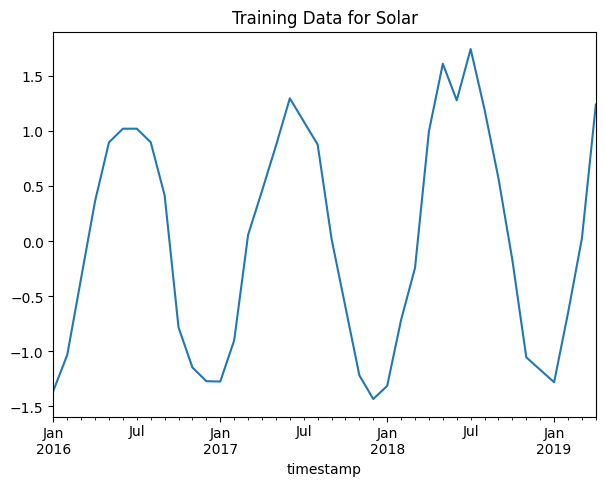

In [22]:
train_univariate[energy_source].plot(figsize=(7,5), title=f'Training Data for {energy_source}')

In [ ]:
# Differentiating the training data
train_univariate_diff = train_univariate[energy_source].diff(12).diff(1).dropna()

<Axes: xlabel='timestamp'>

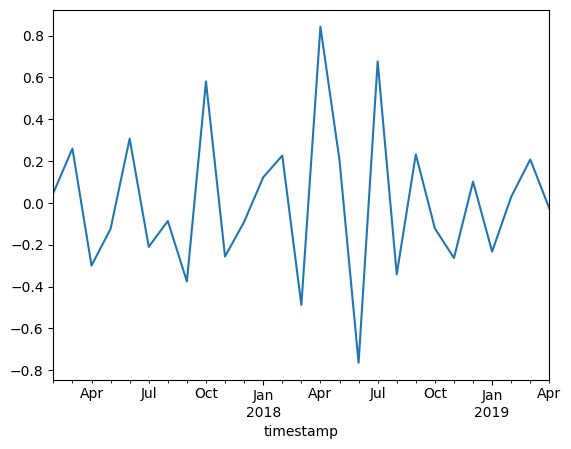

In [24]:
train_univariate_diff.plot()

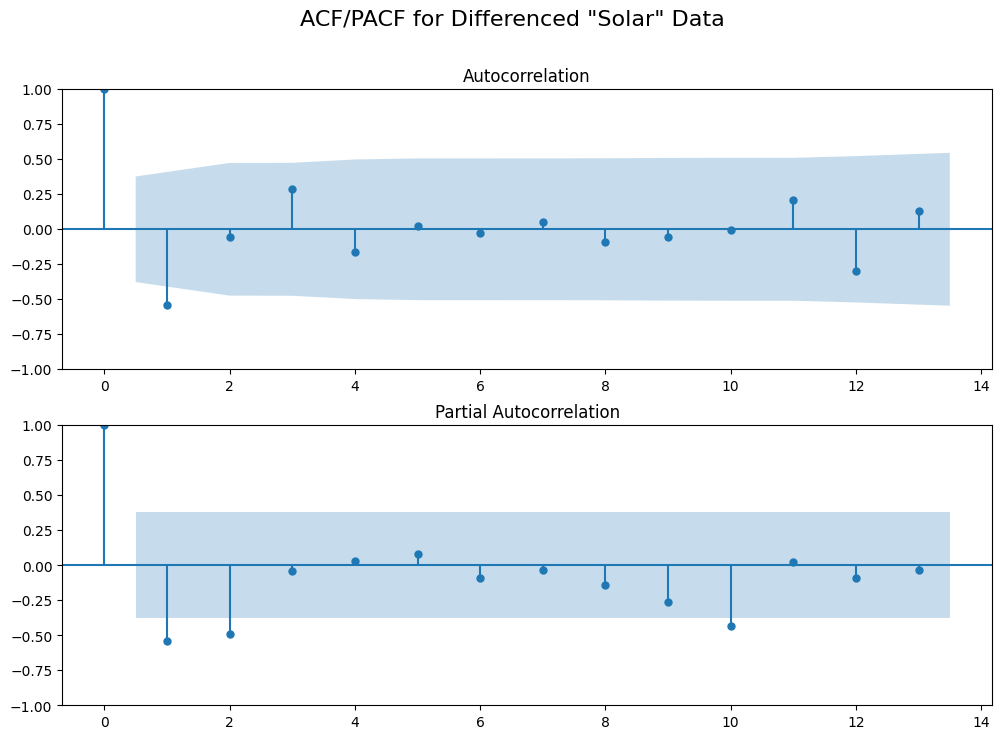

In [ ]:
# Determine SARIMA parameters by analyzing ACF/PACF plots


fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_univariate_diff, lags=13, ax=axes[0])
plot_pacf(train_univariate_diff, lags=13, ax=axes[1])
plt.suptitle(f'ACF/PACF for Differenced "{energy_source}" Data', fontsize=16)
plt.show()

In [ ]:
# Define and fit the SARIMA model
sarima_model_ex = SARIMAX(train_univariate[energy_source], 
                          order=(0, 1, 1),
                          seasonal_order=(1, 1, 0, 12))
sarima_results_ex = sarima_model_ex.fit(disp=False) # disp=False hides convergence output

print(sarima_results_ex.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               Solar   No. Observations:                   40
Model:             SARIMAX(0, 1, 1)x(1, 1, [], 12)   Log Likelihood                  -2.140
Date:                             Mon, 01 Dec 2025   AIC                             10.281
Time:                                     18:14:53   BIC                             14.168
Sample:                                 01-01-2016   HQIC                            11.437
                                      - 04-01-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7219      0.161     -4.490      0.000      -1.037      -0.407
ar.S.L12      -0.3666      

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


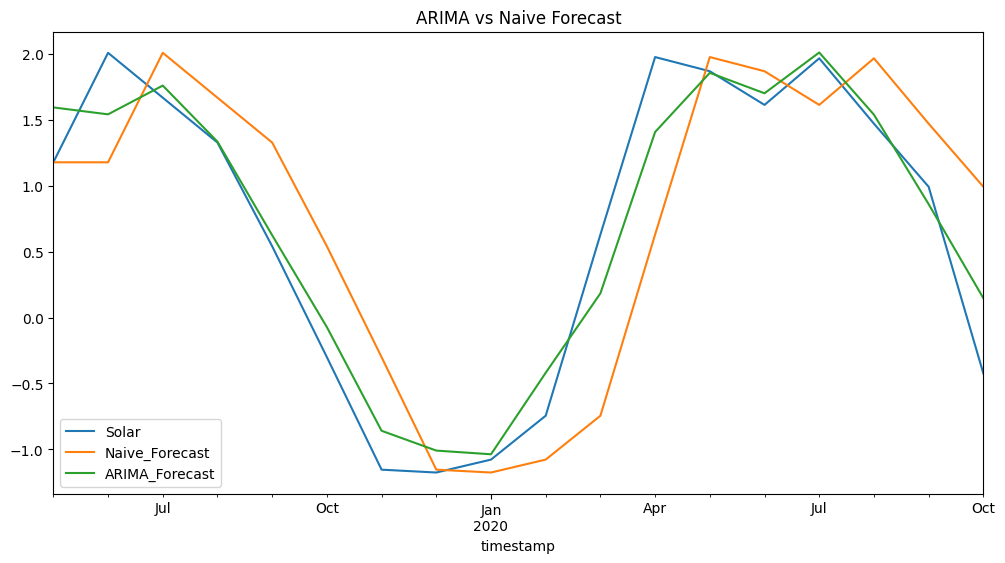

In [ ]:
# Make predictions
# We predict for the same number of steps as the length of our test set
n_steps = len(test_univariate)
arima_pred_ex = sarima_results_ex.get_forecast(steps=n_steps)
arima_pred_mean_ex = arima_pred_ex.predicted_mean
# Add predictions to the test dataframe
test_univariate['ARIMA_Forecast'] = arima_pred_mean_ex
# Step 4: Plot the results
test_univariate.plot(y=[energy_source, 'Naive_Forecast', 'ARIMA_Forecast'], figsize=(12,6), title='ARIMA vs Naive Forecast')
plt.show()


## 3. Automatic Hyperparameter Tuning with `auto_arima`

Manually selecting the right orders for a SARIMA model by inspecting ACF/PACF plots is both an art and a science. It can be time-consuming and requires experience.

A more automated approach is to use a tool that searches through various combinations of parameters and selects the best model based on a statistical criterion, such as the **Akaike Information Criterion (AIC)**. A lower AIC value generally indicates a better-fitting model that doesn't overfit.

The `pmdarima` library provides the `auto_arima` function, which does exactly this. It performs an efficient search to find the optimal `(p,d,q)(P,D,Q)s` combination.

Let's apply `auto_arima` to our 'Solar' energy data.

In [28]:
import pmdarima as pm

# Step 1: Use auto_arima to find the best SARIMA model
# We give it the training data and specify the seasonal period (m=7 for weekly seasonality on daily data)
auto_arima_model = pm.auto_arima(train_preprocessed['value'],
                                 start_p=1, start_q=1,
                                 max_p=3, max_q=3,
                                 max_d=2,
                                 start_P=1,start_Q=1,
                                 max_Q=3, max_P=3,
                                 max_D=2,
                                 m=7,              # Weekly seasonality
                                 seasonal=True,
                                 trace=True,
                                 error_action='ignore',  
                                 suppress_warnings=True, 
                                 stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=1218.253, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=809.014, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=1216.253, Time=0.00 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=996.001, Time=0.02 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.40 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=649.679, Time=0.16 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=1.05 sec
 ARIMA(0,1,1)(0,0,3)[7] intercept   : AIC=539.190, Time=0.31 sec
 ARIMA(0,1,1)(1,0,3)[7] intercept   : AIC=inf, Time=1.47 sec
 ARIMA(0,1,0)(0,0,3)[7] intercept   : AIC=537.217, Time=0.26 sec
 ARIMA(0,1,0)(0,0,2)[7] intercept   : AIC=657.977, Time=0.08 sec
 ARIMA(0,1,0)(1,0,3)[7] intercept   : AIC=inf, Time=1.71 sec
 ARIMA(0,1,0)(1,0,2)[7] intercept   : AIC=39.686, Time=0.47 sec
 ARIM

In [29]:
# Print the summary of the best model found
print(auto_arima_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  510
Model:             SARIMAX(2, 1, 0)x(1, 0, [1], 7)   Log Likelihood                  70.640
Date:                             Mon, 01 Dec 2025   AIC                           -129.280
Time:                                     18:15:12   BIC                           -103.886
Sample:                                 01-01-2022   HQIC                          -119.323
                                      - 05-25-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   7.078e-05   8.74e-05      0.810      0.418      -0.000       0.000
ar.L1         -0.5930      

In [30]:
# Step 2: Make predictions with the best model
auto_arima_pred = auto_arima_model.predict(n_periods=len(test_preprocessed))

In [31]:
# Add the new forecast to our test dataframe
test_preprocessed['Auto_ARIMA_Forecast'] = auto_arima_pred

<Axes: title={'center': 'All Forecasts'}, xlabel='timestamp'>

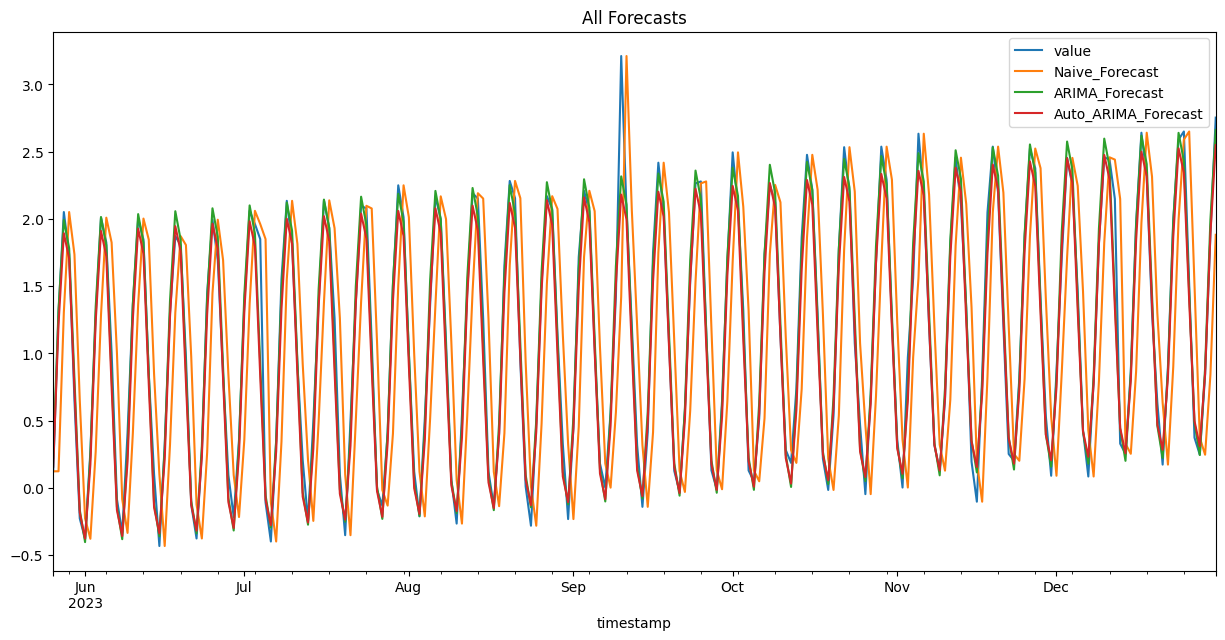

In [32]:
test_preprocessed.plot(y=["value", 'Naive_Forecast', 'ARIMA_Forecast', 'Auto_ARIMA_Forecast'], 
                     figsize=(15, 7), 
                     title=f'All Forecasts')

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Train SARIMA with Autotuning</h2>

Apply what you've learned to the electricity dataset:
1. **Run autoarima**: Set the right seasonal order.
2. **Check the resulting model**
3. **Evaluate**:
   - Compare the results. Did the SARIMA model improve upon the manual selected one?
4. **Select another Target**: Choose another energy source to forecast (e.g., 'Solar' or 'Wind').

This exercise will simplify the building of seasonal time series models.
</div>

In [ ]:
# Use auto_arima to find the best SARIMA model
# We give it the training data and specify the seasonal period (m=12 for yearly seasonality on monthly data)
# We set d=1 and D=1 based on our earlier analysis to guide the search.
auto_arima_model_ex = pm.auto_arima(train_univariate[energy_source],
                                 start_p=1, start_q=1,
                                 max_p=3, max_q=3,
                                 max_d=2,
                                 start_P=1,start_Q=1,
                                 max_Q=3, max_P=3,
                                 max_D=2,
                                 m=12,              # Yearly seasonality
                                 seasonal=True,
                                 trace=True,
                                 error_action='ignore',  
                                 suppress_warnings=True, 
                                 stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=10.829, Time=0.19 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=8.811, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=8.281, Time=0.03 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=8.699, Time=0.03 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=16.162, Time=0.01 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=10.264, Time=0.01 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=8.616, Time=0.03 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=8.003, Time=0.23 sec
 ARIMA(1,0,0)(3,1,1)[12] intercept   : AIC=10.003, Time=0.30 sec
 ARIMA(1,0,0)(2,1,2)[12] intercept   : AIC=10.003, Time=0.22 sec
 ARIMA(1,0,0)(1,1,2)[12] intercept   : AIC=inf, Time=0.29 sec
 ARIMA(1,0,0)(3,1,0)[12] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(1,0,0)(3,1,2)[12] intercept   : AIC=12.003, Time=0.34 sec

In [34]:
# Print the summary of the best model found
print(auto_arima_model_ex.summary())

                                 SARIMAX Results                                  
Dep. Variable:                          y   No. Observations:                   40
Model:             SARIMAX(2, 1, [1], 12)   Log Likelihood                   1.948
Date:                    Mon, 01 Dec 2025   AIC                              6.105
Time:                            18:15:16   BIC                             12.766
Sample:                        01-01-2016   HQIC                             8.141
                             - 04-01-2019                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0302    194.395      0.000      1.000    -380.976     381.037
ar.S.L12      -0.0699    761.930  -9.17e-05      1.000   -1493.425    1493.285
ar.S.L24       0.888

In [ ]:
# Make predictions with the best model
auto_arima_pred_ex = auto_arima_model_ex.predict(n_periods=len(test_univariate))


In [36]:
# Add the new forecast to our test dataframe
test_univariate['Auto_ARIMA_Forecast'] = auto_arima_pred_ex

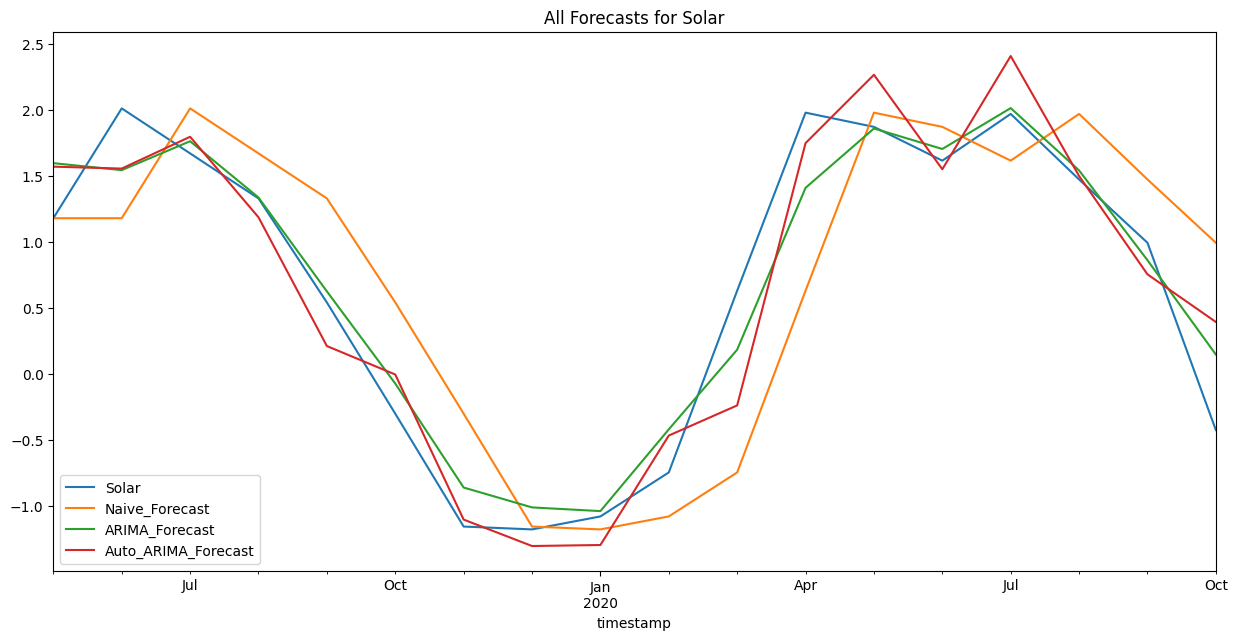

In [ ]:
# Plot all forecasts together
test_univariate.plot(y=[energy_source, 'Naive_Forecast', 'ARIMA_Forecast', 'Auto_ARIMA_Forecast'], 
                     figsize=(15, 7), 
                     title=f'All Forecasts for {energy_source}')
plt.show()

## ✅ Summary 

### What You've Accomplished:

-   **Mastered ARIMA**: You learned the theory behind **ARIMA** models, including how to interpret ACF and PACF plots to manually select the `(p, d, q)` parameters for trend.
-   **Handled Seasonality with SARIMA**: You extended your knowledge to **SARIMA** to account for seasonal patterns, adding the `(P, D, Q, s)` parameters to your modeling toolkit.
-   **Automated Model Selection**: You discovered how to use `pmdarima`'s `auto_arima` function to automatically find the best model parameters, saving significant time and often improving accuracy.

You now have a solid foundation in classical statistical time series forecasting.